# PROBLEMA: CRECIMIENTO DE PRODUCCION DE UN VIVERO

**Estudiante:** DANIEL SEBASTIAN CASTILLO BAQUERO
**Carné:** 1000116730


In [16]:
# Datos de identificación
nombre_estudiante = "DANIEL SEBASTIAN CASTILLO BAQUERO"
carnet = 1000116730


# 1. Descripción del Problema
Un vivero está analizando el crecimiento de la producción de nuevas plantas a partir de un proceso de reproducción controlada.

Se ha observado que el número de nuevas plantas producidas en el mes n sigue el siguiente comportamiento:

• En el mes 0 se produjeron 0 nuevas plantas.

• En el mes 1 se produjo 1 nueva planta.

• A partir del mes 2, el número de nuevas plantas producidas es igual a la suma de las plantas producidas durante los dos meses anteriores, debido a que las plantas que alcanzan su etapa de reproducción generan nuevos brotes siguiendo este patrón de crecimiento.

Relación de recurrencia:
T(n) = 0 si n = 0
T(n) = 1 si n = 1
T(n) = T(n-1) + T(n-2) si n ≥ 2

Determinar con memoización cuántas nuevas plantas serán producidas en el mes n.


## 2\) Requerimientos

 ### Requerimientos funcionales

 1. Recibir un indice entero no negativo.
2. Retornar 0 para el indice 0 y 1 para el indice 1.
3. Para indices mayores o iguales que 2, aplicar la suma de los dos resultados anteriores.
4. Guardar los resultados intermedios en una cache para reutilizarlos y evitar calculos repetidos.
5. Mostrar el resultado calculado.
6. Informar un error cuando la entrada no sea un numero entero o sea negativa.

 ### Requerimientos no funcionales

 1. Tener complejidad de tiempo O(n) gracias a la memoizacion.
2. Mantener identificadores neutrales: `indice`, `cache`, `resolver` y `resultado`.
3. Permitir cambiar los textos de entrada y salida sin modificar la logica del programa.
4. Incluir pruebas para casos base, casos generales y entradas invalidas.

## 3\) Historias de usuario

 ### HU1: ingresar un numero

 Como usuario, quiero ingresar un unico numero para que el sistema realice el calculo.

 **Criterios de aceptacion:**

 - El programa solicita una sola entrada.
- La entrada debe ser un numero entero no negativo.

 ### HU2: consultar un resultado

 Como usuario, quiero recibir el resultado despues de ingresar el numero.

 **Criterios de aceptacion:**

 - Con indice 10, el resultado es 55.
- El programa muestra el resultado sin pedir informacion adicional.

 ### HU3: conservar los casos base

 Como usuario, quiero que los indices iniciales produzcan resultados correctos.

 **Criterios de aceptacion:**

 - El indice 0 retorna 0.
- El indice 1 retorna 1.

 ### HU4: evitar recálculos

 Como usuario, quiero que se guarden resultados previos para que el calculo sea eficiente.

 **Criterios de aceptacion:**

 - Cada valor calculado se guarda en la cache.
- Un resultado guardado se reutiliza cuando vuelve a ser necesario.

 ### HU5: validar la entrada

 Como usuario, quiero recibir un mensaje claro si el indice no es valido.

 **Criterios de aceptacion:**

 - Un valor negativo genera `ValueError`.
- Un valor no entero genera `TypeError`.

## 4) Diagrama de flujo
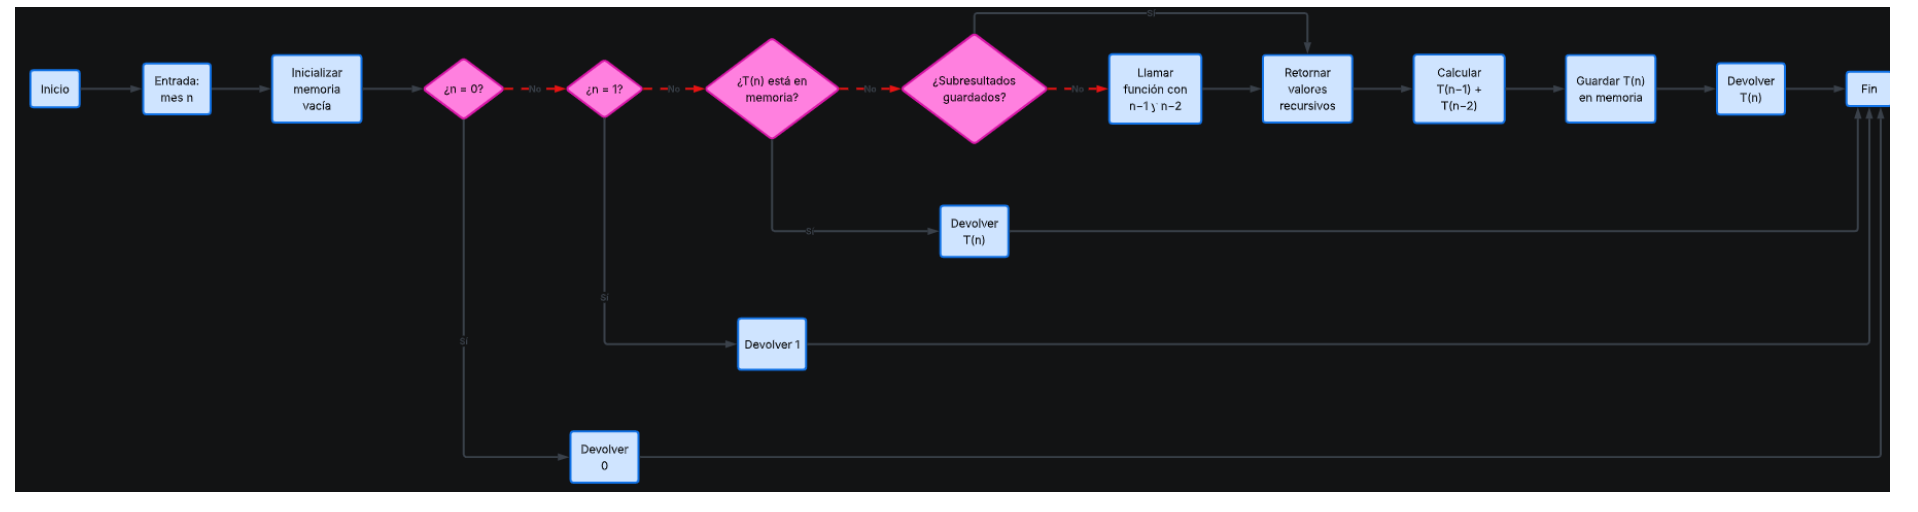

## 5) Análisis de complejidad

Sin cache, se repetirian subproblemas ya calculados. Con memoizacion, cada indice desde 0 hasta el indice solicitado se resuelve una sola vez.

La recurrencia de valores es:

$$T(0)=0, \quad T(1)=1, \quad T(n)=T(n-1)+T(n-2).$$

Para el costo de la implementación memoizada:

$$C(0)=C(1)=\Theta(1), \qquad C(n)=C(n-1)+\Theta(1).$$

| Caso | Tiempo | Explicación |
|---|---:|---|
| Indice 0 o 1 | Θ(1) | Se devuelve un caso base. |
| Indice mayor o igual que 2 | Θ(n) | Cada resultado se calcula y guarda una vez. |

La memoria usada por la cache y las llamadas recursivas es Θ(n). Sin memoizacion, el tiempo creceria aproximadamente como O(2^n).


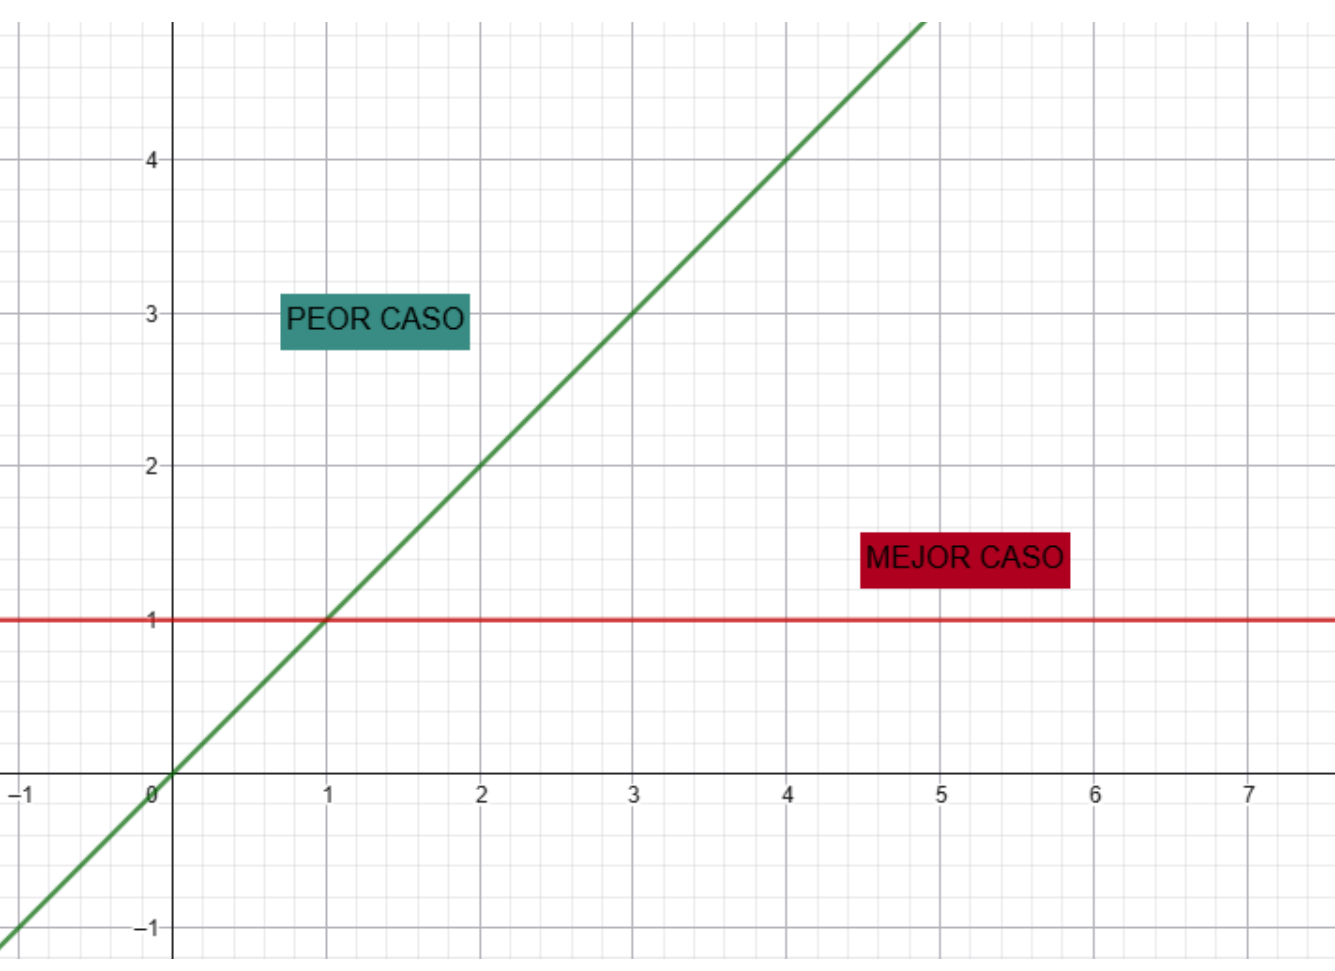

## 6) Código funcional

In [17]:
def valor(indice: int) -> int:

    if isinstance(indice, bool) or not isinstance(indice, int):
        raise TypeError("El indice debe ser un num entero.")
    if indice < 0:
        raise ValueError("El indice debe ser mayor o igual que 0.")
    cache = {0: 0, 1: 1}
    def resolver(indice_actual: int) -> int:

        if indice_actual in cache:
            return cache[indice_actual]
        
        cache[indice_actual] = (resolver(indice_actual - 1) + resolver(indice_actual - 2))
        return cache[indice_actual]

    return resolver(indice)


def solicitar_indice() -> int:
    entrada = input("Ingrese el num del mes: ").strip()
    try:
        return int(entrada)
    except ValueError as error:
        raise ValueError("Tiene que escribir un num entero") from error


def main() -> None:
    try:
        indice = solicitar_indice()
        resultado = valor(indice)
    except (TypeError, ValueError) as error:
        print(f"Error: {error}")
        return

    print(f"En el mes {indice} habran: {resultado} plantas")

main()


En el mes 10 habran: 55 plantas


## 7) Tests aplicados

| Índice | Matas |
|---:|---:|
| 0 | 0 |
| 1 | 1 |
| 2 | 1 |
| 6 | 8 |
| 10 | 55 |
| 20 | 6765 |

In [18]:
casos_validos = {0: 0, 1: 1, 2: 1, 3: 2, 6: 8, 10: 55, 20: 6765,}

for indice, esperado in casos_validos.items():
    assert valor(indice) == esperado, f"Falla el índice {indice}"

try:
    valor(-1)
except ValueError:
    pass
else:
    raise AssertionError("Se esperaba ValueError para un indice negativo.")

for entrada_invalida in ("10", True):
    try:
        valor(entrada_invalida)
    except TypeError:
        pass
    else:
        raise AssertionError(f"Se esperaba TypeError para {entrada_invalida!r}.")

print("Todos los tests se ejecutaron bien.")
print(f"Ejemplo: indice 10 -> valor {valor(10)}")


Todos los tests se ejecutaron bien.
Ejemplo: indice 10 -> valor 55
